In [1]:
from dotenv import load_dotenv
load_dotenv()

True

### Подключимся в gemini

In [2]:
from openai import OpenAI
import os

model_name = "models/gemini-2.5-flash"
model_name = "models/gemini-3.1-flash-lite"

client = OpenAI(
    api_key=os.getenv('GEMINI_API_KEY'),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

response = client.chat.completions.create(

    model=model_name, 
    messages=[
        {"role": "user", "content": "Привет! Как ты называешься gemini-3.1-flash-lite или gemini-2.5-flash?"}
    ]
)

print(response.choices[0].message.content)

Привет! Я — большая языковая модель, обученная Google.

На данный момент у меня нет версии с названиями «gemini-3.1-flash-lite» или «gemini-2.5-flash». Это вымышленные или будущие названия. 

В текущей линейке моделей Google актуальными являются модели семейства **Gemini 1.5** (например, Gemini 1.5 Pro и Gemini 1.5 Flash).


### Сделаем функцию вызова модели, которая будет принимать на вход вопрос и возвращать ответ от модели

In [3]:
def llm(prompt):
    # response = openai_client.responses.create(
    #     model='gpt-5.4-mini',
    #     input=prompt

    response = client.chat.completions.create(

    model=model_name, 
    messages=[
        {"role": "user", "content": prompt}
    ]
    )
    return response.choices[0].message.content

In [4]:
llm("Hey, what's up?")

"Not much! Just hanging out in the digital void, ready to help you with whatever you need. How’s your day going? What's on your mind?"

In [5]:
question = 'I just discovered the course. Can I join now?'
answer = llm(question)
print(answer)

To give you the most accurate answer, **could you tell me which course you are referring to?**

If you can provide the **name of the course** or the **platform** (e.g., Coursera, Udemy, a university program, or a specific bootcamp), I can help you figure out how to join.

In the meantime, here are a few things you should check:

1.  **Check the "Enrollment" Status:** Look at the course page to see if it says "Open for Enrollment," "Waitlist," or "Closed."
2.  **Self-Paced vs. Cohort-Based:** 
    *   If it is **self-paced**, you can usually join and start at any time.
    *   If it is **cohort-based** (meaning everyone learns together on a schedule), you may have to wait for the next session if the current one has already started.
3.  **Check for "Audit" Options:** Some platforms (like edX or Coursera) allow you to "audit" a course for free even after it has started, which gives you access to the materials even if you missed the official start date.

**Once you reply with the course na

### Чтобы модель понимала в промте контекст, добавим его в виде системного сообщения:

In [6]:
context = '''
I just discovered the course. Can I still join?
Yes, but if you want to receive a certificate, you need to submit your project while we're still accepting submissions.

Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

What is the video/zoom link to the stream for the "Office Hours" or live/workshop sessions?
The zoom link is only published to instructors/presenters/TAs. Students participate via YouTube Live and submit questions to Slido.

Cloud alternatives with GPU
Check the quota and reset cycle carefully. Potential options include Google Colab, Kaggle, Databricks.
'''

prompt = f'''
Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."

Question:
{question}

Context:
{context}
'''

answer = llm(prompt)
print(answer)

Yes, you can join now, but if you want to receive a certificate, you need to submit your project while submissions are still being accepted.


#### Еще можно добавить system prompt, который будет задавать тон и стиль ответа модели. Например:

In [7]:
def llm_rag(context, question):
    response = client.chat.completions.create(
        model='models/gemini-3.1-flash-lite',
        messages=[
            {
                "role": "system", 
                "content": "Ты — помощник курса LLM Zoomcamp. Отвечай только на основе предоставленного контекста. Если информации нет — честно говори 'Я не знаю'."
            },
            {
                "role": "user", 
                "content": f"Контекст: {context}\n\nВопрос: {question}"
            }
        ],
        temperature=0.0 # Для RAG лучше ставить 0, чтобы ответы были стабильными
    )
    return response.choices[0].message.content

In [8]:
llm_rag(context, question)

'Да, вы можете присоединиться. Однако, если вы хотите получить сертификат, вам необходимо сдать проект до того, как прием работ будет закрыт.'

In [9]:

llm_rag(context, 'Сколько дней пограничника в году?')

'Я не знаю.'

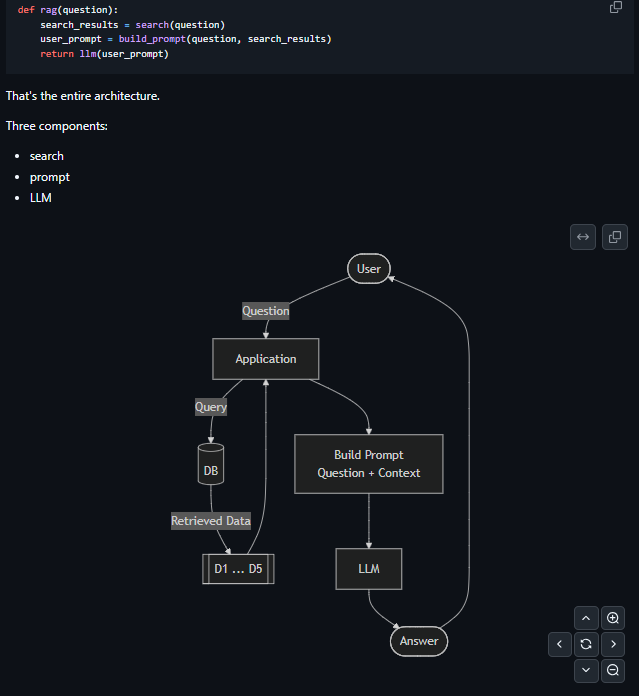

### 4 Dataset

https://github.com/DataTalksClub/llm-zoomcamp/blob/main/01-intro/lessons/04-dataset.md

In [10]:
import requests

docs_url = 'https://datatalks.club/faq/json/courses.json'
response = requests.get(docs_url)
courses_raw = response.json()

In [11]:
courses_raw

[{'course': 'machine-learning-zoomcamp',
  'course_name': 'ML Zoomcamp',
  'path': '/json/machine-learning-zoomcamp.json',
  'questions_count': 472},
 {'course': 'llm-zoomcamp',
  'course_name': 'LLM Zoomcamp',
  'path': '/json/llm-zoomcamp.json',
  'questions_count': 79},
 {'course': 'data-engineering-zoomcamp',
  'course_name': 'Data Engineering Zoomcamp',
  'path': '/json/data-engineering-zoomcamp.json',
  'questions_count': 402},
 {'course': 'mlops-zoomcamp',
  'course_name': 'MLOps Zoomcamp',
  'path': '/json/mlops-zoomcamp.json',
  'questions_count': 255}]

In [12]:
documents = []
url_prefix = 'https://datatalks.club/faq'

for course in courses_raw:
    course_url = f'{url_prefix}{course['path']}'

    course_response = requests.get(course_url)
    course_response.raise_for_status()
    course_data = course_response.json()

    documents.extend(course_data)

len(documents)

1208

Each entry has:

- id - unique identifier
- course - course slug (e.g., machine-learning-zoomcamp)
- section - which section of the course
- question - the FAQ question
- answer - the FAQ answer

In [13]:
documents[0]

{'id': '0e38656cfb',
 'course': 'machine-learning-zoomcamp',
 'section': 'General Course-Related Questions',
 'question': 'How do I submit homework?',
 'answer': "- Do the tasks locally\n- Publish your code (e.g., in your own GitHub repo)\n- Submit your answers via the homework form and include the URL to your code\n- You will see the answers only after the deadline\n- Homeworks are in the cohorts folder, e.g. for 2025 it's [`cohorts/2025`](https://github.com/DataTalksClub/machine-learning-zoomcamp/tree/master/cohorts/2025)\n- The forms for submitting the homework are in the [course management platform](https://courses.datatalks.club/)"}

Using this data
In the RAG pipeline, this dataset is our knowledge base:

- We index all the documents (the search step)
- When a student asks a question, we search the index
- The search returns the most relevant FAQ entries
- We give those entries to the LLM as context
- The LLM generates an answer based on the context

#### 5 Search

minsearch is a simple in-memory search engine. 

It's a toy implementation - not production ready - but it illustrates how search engines work and it gives good results.

In [14]:
from minsearch import Index

index = Index(
    text_fields=['question', 'section', 'answer'],
    keyword_fields=['course']
)

index.fit(documents)

In [15]:
question = 'I just discovered the course. Can I join now?'

search_results = index.search(
    question,
    #filter_dict={'course': 'llm-zoomcamp'},
    num_results=5
)

search_results

[{'id': '74eb249bbf',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.'},
 {'id': '41aabbd7c5',
  'course': 'machine-learning-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'The course has already started. Can I still join it?',
  'answer': 'Yes, you can. Even though you missed the start date, you can register for the course. You won’t be able to submit some of the homeworks, but you can still take part in the course.\n\nIn order to get a certificate, you need to submit 2 out of 3 course projects and review 3 peers by the deadline. It means that if you join the course at the end of November and manage to work on two projects, you will still be eligible for a certificate.'},
 {'id': '9e508f2212',
  'course': 'data-engineering-zoomcamp',
 

In [16]:
question = 'I just discovered the course. Can I join now?'

search_results = index.search(
    question,
    filter_dict={'course': 'llm-zoomcamp'},
    num_results=5
)

search_results

[{'id': '74eb249bbf',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.'},
 {'id': '977bf7786c',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
  'answer': "You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date."},
 {'id': '69d122f12e',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Certificate: Can I follow the course in a self-paced mode and get a certificate?',
  'answer': 'No, you c

In [17]:
question = 'I just discovered the course. Can I join now?'

search_results = index.search(
    question,
    boost_dict={'question': 2.0, 'section': 0.5},
    filter_dict={'course': 'llm-zoomcamp'},
    num_results=5
)

search_results

[{'id': '74eb249bbf',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.'},
 {'id': '977bf7786c',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
  'answer': "You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date."},
 {'id': '69d122f12e',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Certificate: Can I follow the course in a self-paced mode and get a certificate?',
  'answer': 'No, you c

In [18]:
[doc['question'] for doc in search_results]

['I just discovered the course. Can I still join?',
 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
 'Certificate: Can I follow the course in a self-paced mode and get a certificate?',
 'When will the course be offered next?',
 'I missed the first homework - can I still get a certificate?']

In [19]:
results = index.search(
    question,
    num_results=5,
    boost_dict={'question': 2.0, 'section': 0.5} # question field is more important than section field, 2x vs 0.5x, 
    # by default all fields are equally important, 1.0
)

In [20]:
results = index.search(
    question,
    num_results=5, # how many results to return, 10 by default
    filter_dict={'course': 'mlops-zoomcamp'} # only search in mlops-zoomcamp course documents
)

In [21]:
[doc['question'] for doc in results]

['Course - Can I still join the course after the start date?',
 'Homework: Just found this course, can I still submit homeworks?',
 'I forgot if I registered, can I still join the zoomcamp?',
 'Certificate - Can I follow the course in a self-paced mode and get a certificate?',
 'Course: How do I start?']

In [22]:
def search(question, course='llm-zoomcamp'):
    """Search for relevant documents based on the question and course.
    Args:
        question (str): The question to search for.
        course (str): The course to filter documents by. Default is 'llm-zoomcamp'.
    Returns:
        list: A list of relevant documents matching the search criteria.
    """
    boost_dict = {'question': 2.0, 'section': 0.5} # question field is more important than section field, 2x vs 0.5x
    filter_dict = {'course': course}

    return index.search(
        question,
        boost_dict=boost_dict,
        filter_dict=filter_dict,
        num_results=5
    )

In [23]:
search_results = search(question)

### 6 building-promt

Нам нужно создать подсказку, включающую вопрос пользователя и поиск результаты.

Обычно при создании систем искусственного интеллекта подсказка состоит из двух частей:

Инструкции (также называемые системными подсказками): они сообщают LLM, как это сделать вести себя. Он никогда не меняется — он одинаков для каждого запроса.

Промпт пользоватея: она меняется с каждым запросом. Он содержит фактическое вопрос и полученный контекст.
Инструкции

In [24]:
# Инструкции рассказывают LLM о его роли и о том, как на нее ответить:
INSTRUCTIONS = '''
Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."
'''
# Шаблон пользовательского запроса содержит заполнители для вопроса и контекста:
USER_PROMPT_TEMPLATE = ''' 
Question:
{question}

Context:
{context}
'''

In [25]:
# The context представляет собой отформатированную строку со всеми результатами поиска:
def build_context(search_results):
    lines = []

    for doc in search_results:
        lines.append(doc['section'])
        lines.append('Q: ' + doc['question'])
        lines.append('A: ' + doc['answer'])
        lines.append('')

    return '\n'.join(lines).strip()

# Каждый документ становится блоком с разделом, вопросом и ответом. Этот формат облегчает чтение LLM. 
# Мы только что повернули словарь в строку — ничего особенного.

In [26]:
# Теперь мы объединяем вопрос с контекстом в пользовательской подсказке:

def build_prompt(question, search_results):
    """ Build a prompt for the LLM by combining the question and search results."""
    context = build_context(search_results)
    prompt = USER_PROMPT_TEMPLATE.format(
        question=question,
        context=context
    )
    return prompt.strip() # убираем лишние пробелы в начале и конце, если они есть

In [27]:
prompt = build_prompt(question, search_results)

print(prompt)

Question:
I just discovered the course. Can I join now?

Context:
General Course-Related Questions
Q: I just discovered the course. Can I still join?
A: Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.

General Course-Related Questions
Q: Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
A: You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

General Course-Related Questions
Q: Certificate: Can I follow the course in a self-paced mode and get a certificate?
A: No, you can only get a certificate if you finish the course with a "live" cohort.

We don't award certificates for the self-paced mode. The reason is you need to peer-review 3 capstone(s) after submitting your project

### 7 llm

In [28]:
llm_rag(context=INSTRUCTIONS, question=prompt)

'Yes, you can join now, but if you want to receive a certificate, you need to submit your project while submissions are still being accepted.'

In [29]:
response = client.chat.completions.create(
        model='models/gemini-3.1-flash-lite',
        messages=[
            {
                "role": "system", 
                "content":INSTRUCTIONS,
            },
            {
                "role": "user", 
                "content": prompt
            }
        ],
        temperature=0.0 # Для RAG лучше ставить 0, чтобы ответы были стабильными
    )
response.choices[0].message.content

'Yes, you can still join, but if you want to receive a certificate, you need to submit your project while submissions are still being accepted.'

In [30]:
response.choices[0]

Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Yes, you can still join, but if you want to receive a certificate, you need to submit your project while submissions are still being accepted.', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, extra_content={'google': {'thought_signature': 'EjQKMgEMOdbH6sff3WkR0ls7S/tErjT1O4go1S+i08BuO1FK39yxfawmMZBHMauOQB+LHtjh'}}))

In [31]:
response.usage

CompletionUsage(completion_tokens=29, prompt_tokens=412, total_tokens=441, completion_tokens_details=None, prompt_tokens_details=None)

In [32]:
# Посмотреть весь объект целиком
print(response.usage)
# Выведет что-то вроде: 
# CompletionUsage(completion_tokens=42, prompt_tokens=350, total_tokens=392)

# Доступ к конкретным цифрам:
print(f"Входящие токены: {response.usage.prompt_tokens}")
print(f"Исходящие токены: {response.usage.completion_tokens}")
print(f"Всего потрачено: {response.usage.total_tokens}")

CompletionUsage(completion_tokens=29, prompt_tokens=412, total_tokens=441, completion_tokens_details=None, prompt_tokens_details=None)
Входящие токены: 412
Исходящие токены: 29
Всего потрачено: 441


In [33]:
input_price = 0.75 / 1_000_000
output_price = 4.50 / 1_000_000

cost = (
    response.usage.prompt_tokens * input_price +
    response.usage.completion_tokens * output_price
)

cost

0.0004395

In [34]:
def llm(instructions, user_prompt, model='models/gemini-3.1-flash-lite'):
    # Заменяем 'developer' на 'system', так как шлюз Gemini ожидает именно эту роль
    message_history = [
        {'role': 'system', 'content': instructions},
        {'role': 'user', 'content': user_prompt}
    ]

    # Используем стандартный интерфейс SDK
    response = client.chat.completions.create(
        model=model,
        messages=message_history,
        temperature=0.0 # Фиксируем температуру на 0 для предсказуемости RAG
    )

    # Достаем текст из стандартизированного объекта ответа
    return response.choices[0].message.content

def rag(query, model='models/gemini-3.1-flash-lite'):

    search_results = search(query)
    prompt = build_prompt(query, search_results)
    answer = llm(INSTRUCTIONS, prompt, model=model)
    
    return answer

In [35]:
answer = rag('I just discovered the course. Can I join now?')
print(answer)

Yes, you can still join, but if you want to receive a certificate, you need to submit your project while submissions are still being accepted.


In [36]:
rag('How do I get a certificate?')

'To get a certificate, you must finish the course with a "live" cohort and pass the Capstone project. Certificates are not awarded for the self-paced mode because you are required to peer-review 3 capstone projects, which can only be done while the course is running. \n\nAdditionally, ensure you have entered your official name in the "Edit Course Profile" section if you do not want a randomly assigned name (like "Lucid Elbakyan") to appear on your certificate.'

In [37]:
rag('Who is the greatest NHL player of all time?')

"I don't know."

### 8 rag-helper

In [42]:

from dotenv import load_dotenv
load_dotenv()

from ingest import load_faq_data
from rag_helper import RAGBase
from openai import OpenAI

documents = load_faq_data()
index = build_index(documents)

client = OpenAI(
    api_key=os.getenv('GEMINI_API_KEY'),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

assistant = RAGBase(
    index=index,
    llm_client=client,
)

answer = assistant.rag('I just discovered the course. Can I join now?')
print(answer)

ImportError: cannot import name 'load_faq_data' from 'ingest' (/workspaces/llm-zoomcamp-2026-code/ingest.py)

In [ ]:
client = OpenAI(
    api_key=os.getenv('GEMINI_API_KEY'),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

response = client.chat.completions.create(

    model=model_name, 
    messages=[
        {"role": "user", "content": "Привет! Как ты называешься gemini-3.1-flash-lite или gemini-2.5-flash?"}
    ]
)

### 9 Data-imngestion

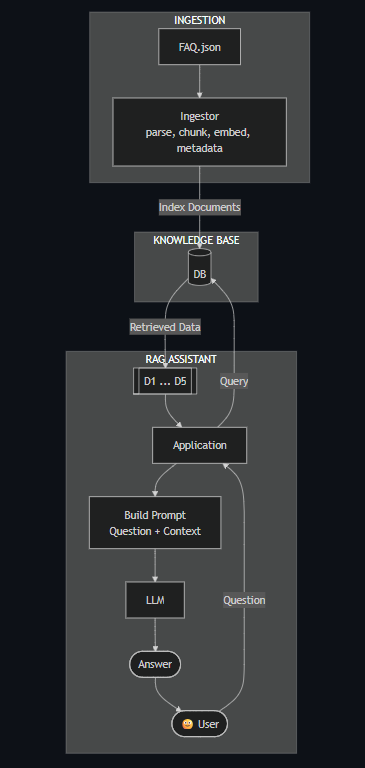

### 10 Next steps